In [9]:
import jax
jax.config.update("jax_enable_x64", True)

# A second model: non-linear reaction-diffusion equation
This notebook assumes that you have read the previous on the heat equation. If you are unfamiliar with finite discretization schemes for PDEs, please refer to the previous notebook on the heat equation for a (very) short introduction.  We now consider the nonlinear KPP-Fisher reaction diffusion-equation with zero Dirichlet boundary condition:

$$
\begin{aligned}
&\frac{\partial u}{\partial t} = \nu\Delta u + ru(1-u) \quad && (x,t) \in (0, T) \times (0,1)\\
& u(t, 0) = u(t, 1) = 0 \quad && x \in \{0,1\}\\
& u(0, x)= u_0 \quad && x \in [0,1]
\end{aligned}
$$
After discretization using a finite difference scheme  $\mathbf{u}^t_i = u(t, x_i)$ , the resulting ODE system is 
$$
\frac{d\mathbf{u}}{dt}(t) = \nu A \mathbf{u}(t) + f(\mathbf{u})
$$
where $f(\mathbf{u})_i = r\mathbf{u}_i(1-\mathbf{u}_i)$. Here we will aim to recover the reaction parameters $r$.


In [10]:

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist

import dynestyx as dsx
from dynestyx import ContinuousTimeStateEvolution, DynamicalModel, LinearGaussianObservation
import diffrax as dfx


import jax.random as jr
from numpyro.infer import Predictive

from dynestyx import ODESimulator
from dynestyx import Filter
from dynestyx.inference.filter_configs import ContinuousTimeEnKFConfig



In [11]:
# Discretization parametes (if the simulation is too slow, try reducing these)
spatial_discretization = 2**6
dt = 1e-2 # (only an initial guess, the ODE solver will adaptively choose the time step)
obs_time = jnp.linspace(0, 1, 2**6)

In [12]:
# Building the discrete laplacian operator for the heat equation (interior nodes only)
nu = 1e-2  # diffusion coefficient
key = jr.PRNGKey(42)
r_true = dist.Gamma(concentration=1.0, rate=1.0).sample(key) # sample the true reaction rate from a prior distribution
print("True r:", float(r_true))


n = spatial_discretization
x_full = jnp.linspace(0, 1, n, endpoint=True)
h = x_full[1] - x_full[0]
x = x_full[1:-1]  # interior nodes; boundary values are fixed at 0 by the Dirichlet BC

n_interior = n - 2
A = (jnp.diag(-2.0 * jnp.ones(n_interior))
     + jnp.diag(jnp.ones(n_interior - 1), 1)
     + jnp.diag(jnp.ones(n_interior - 1), -1)) / h**2 * nu
     
f = lambda x: r_true * x * (1 - x)  # reaction term


True r: 1.091723649484995


In [13]:
# define the initial condition a function of x.
def initial_condition(x):
    mu = 0.5
    envelope = jnp.exp(-(x - mu)**2 / (2 * 0.5**2)) * jnp.sin(jnp.pi * x)
    wiggle = 1.0 + 0.3 * jnp.sin(6 * jnp.pi * x)
    return 0.8 * envelope * wiggle

ic_noise = 1e-2 # the noise on the initial condition
obs_noise = 1e-2 # the noise on the observations

def reaction_diffusion_equation_model(r=None, obs_times=None, obs_values=None, predict_times=None):
    r = numpyro.sample("r", dist.Gamma(concentration=1.0, rate=1.0), obs=r)

    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            loc=initial_condition(x), covariance_matrix=ic_noise**2 * jnp.eye(n_interior)
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=lambda x, u, t: A @ x + r * x * (1 - x),
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.eye(n_interior), R=obs_noise**2 * jnp.eye(n_interior)
        ),
    )
    return dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values, predict_times=predict_times)

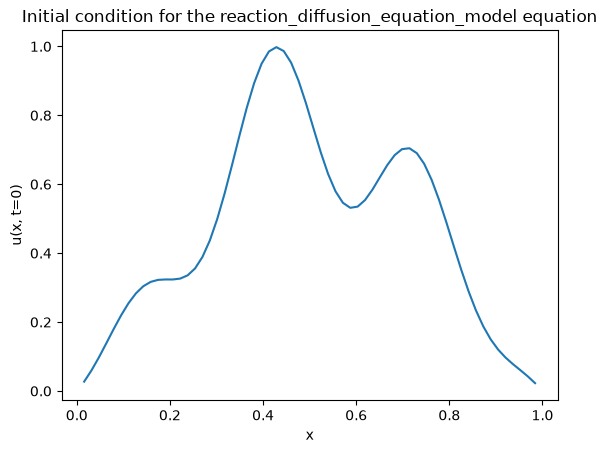

In [14]:
plt.plot(x, initial_condition(x))
plt.title("Initial condition for the reaction_diffusion_equation_model equation")
plt.xlabel("x")
plt.ylabel("u(x, t=0)")
plt.show()

## Generating the solution 

In [15]:
prng_key = jr.PRNGKey(0)
key, subkey = jr.split(prng_key)
predictive_model = Predictive(reaction_diffusion_equation_model, num_samples=1)

with ODESimulator(
    solver=dfx.ImplicitEuler(), # note the use of an implicit solver.
    stepsize_controller=dfx.PIDController(rtol=1e-5, atol=1e-5),
    dt0=dt,
    max_steps=10**6,
):
    pde_solution = predictive_model(predict_times=obs_time, obs_values=None, r=r_true, rng_key=subkey)

## Visualizing the solution

We plot the sampled realization as a space-time heatmap. Since we solved for the interior nodes only, we pad the state back out with the (fixed, zero) Dirichlet boundary values before plotting.

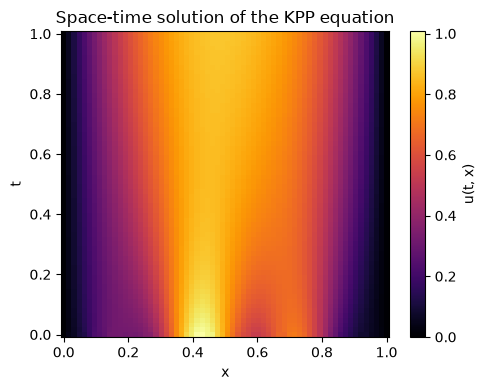

In [16]:
u = pde_solution["f_states"][0, 0]  # (n_times, n_interior)
u_full = jnp.pad(u, ((0, 0), (1, 1)))  # add back the fixed zero boundary values

fig, ax = plt.subplots(figsize=(5, 4))
mesh = ax.pcolormesh(x_full, obs_time, u_full, shading="auto", cmap="inferno")
fig.colorbar(mesh, ax=ax, label="u(t, x)")
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_title("Space-time solution of the KPP equation")
plt.tight_layout()
plt.show()

# Inferring the reaction rate by running MCMC through the simulator

`reaction_diffusion_equation_model` is fully deterministic given `r` (no process noise, small-noise Gaussian
observation model), so we run NUTS directly under `ODESimulator`: NUTS backpropagates
straight through the PDE solve ("unrolling"), the same "direct simulation" pattern used
for the heat equation. 

In [17]:
from numpyro.infer import MCMC, NUTS
from numpyro.infer.reparam import LocScaleReparam
from numpyro.handlers import reparam

with ODESimulator(
    solver=dfx.ImplicitEuler(),
    stepsize_controller=dfx.PIDController(rtol=1e-5, atol=1e-5),
    dt0=dt,
    max_steps=10**6,
):
    nuts_kernel = NUTS(reaction_diffusion_equation_model, step_size=1e-4)
    mcmc = MCMC(nuts_kernel, num_warmup=50, num_samples=25)
    mcmc.run(
        jr.PRNGKey(1),
        obs_times=pde_solution["f_times"][0, 0],
        obs_values=pde_solution["f_observations"][0, 0],
    )
posterior = mcmc.get_samples()
print("Posterior r mean:", float(jnp.mean(posterior["r"])))
print("Posterior r std:", float(jnp.std(posterior["r"])))
print("True r:", float(r_true))

sample: 100%|██████████| 75/75 [01:50<00:00,  1.48s/it, 255 steps of size 1.62e-03. acc. prob=0.85] 


Posterior r mean: 1.0895972102153126
Posterior r std: 0.0027094033006313
True r: 1.091723649484995


# Inference with the continuous time Ensemble Kalman filter

Similarly, we can run a continuous time Ensemble Kalman filter as an alternative to running MCMC through the simulation. 

In [18]:
def filtered_parameter_model():
    with Filter(
        filter_config=ContinuousTimeEnKFConfig( # continuous-time ensemble Kalman filter
            record_filtered_states_mean=True,
        )
    ):
        return reaction_diffusion_equation_model(obs_times=pde_solution["f_times"][0, 0], obs_values=pde_solution["f_observations"][0, 0])

nuts = NUTS(filtered_parameter_model)
mcmc = MCMC(nuts, num_warmup=75, num_samples=75)
mcmc.run(jr.PRNGKey(2))
posterior = mcmc.get_samples()

sample: 100%|██████████| 150/150 [02:34<00:00,  1.03s/it, 7 steps of size 2.04e-01. acc. prob=0.95] 


In [19]:
print("Posterior r mean:", float(jnp.mean(posterior["r"])))
print("Posterior r std:", float(jnp.std(posterior["r"])))
print("True r:", float(r_true))

Posterior r mean: 1.0946497820379353
Posterior r std: 0.0031052409082442454
True r: 1.091723649484995
